# 22. Evaluating AI Outputs in Causal Workflows

If AI is going to help with causal inference, we need to evaluate the outputs like production artifacts. A fluent answer is not enough. We need tests for design selection, variable timing, bad controls, unsupported claims, hallucinated columns, missing diagnostics, and brittle behavior across reruns.

This notebook builds a small evaluation harness for AI-generated causal workflow artifacts. It combines gold labels, deterministic graders, regression-test summaries, optional local LLM runs, and all-model comparison.

## Mathematical Core

Evaluation requires task-level ground truth or expert labels. For cases $i=1, \ldots, n$, define pass indicators $P_i$ for valid outputs and hallucination indicators $H_i$ for unsupported claims:

$$
\widehat{\mathrm{pass}} = \frac{1}{n}\sum_{i=1}^{n} P_i,
$$

$$
\widehat{\mathrm{hallucination}} = \frac{1}{n}\sum_{i=1}^{n} H_i.
$$

For structured causal workflows, the rubric should also check whether the output identifies $(A, Y, \mathcal{P}, T, \theta)$ and names assumptions. A high fluency score has little value if these formal fields are wrong or missing.


## Learning Goals

By the end of this notebook, you should be able to:

- Build evaluation cases for AI-assisted causal workflows.
- Define structured output schemas for causal workflow answers.
- Score design choice, variable-role reasoning, diagnostics, recommendation conservatism, and hallucinated columns.
- Measure blocker recall for high-risk causal mistakes.
- Compare candidate outputs and model families on the same rubric.
- Build regression tests that detect prompt/model drift.
- Explain why LLM-based evaluation is useful but brittle.

## Live Model Note

Evaluation notebooks are brittle in a subtle way: the grader can become as unstable as the system being graded. A model may pass a case because it uses the right words without the right reasoning, or fail because it states the right idea with unexpected language.

We will therefore start with deterministic graders. Optional live LLM outputs are treated as empirical observations. If outputs change across reruns, that is not an annoyance; it is exactly the kind of instability an evaluation harness should reveal.

## 1. Setup

The evaluation harness will use structured JSON outputs. For live local models, we reuse the shared Hugging Face helper and clear model memory between model families.

In [1]:
# Section focus: 1. Setup.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

import json
import re
import sys
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'local_llm.py').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

from notebooks._shared.display import smart_display


Project root: /home/apex/Documents/portfolio


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

MODEL_ID = 'Qwen/Qwen2.5-14B-Instruct'
MAX_NEW_TOKENS = 1900
COMPACT_MAX_NEW_TOKENS = 850
TEMPERATURE = 0.0
SEED = 222
MODEL_COMPARISON_CASE_LIMIT = 3

try:
    import torch
    print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
except Exception as exc:
    print(f'Torch availability check failed: {exc}')

CUDA available to this kernel: True


In [3]:
try:
    from notebooks._shared.local_llm import DEFAULT_MODELS_TO_COMPARE
except Exception:
    DEFAULT_MODELS_TO_COMPARE = [('Qwen 14B', MODEL_ID, 'strong local analysis')]

MODELS_TO_COMPARE = DEFAULT_MODELS_TO_COMPARE
pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])

,label,model_id,role
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test
1,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default
2,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis
3,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison
6,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison
7,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison
8,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline


## 2. What Should We Evaluate?

For causal workflows, the evaluation target is decision safety as well as answer quality.

We want to know whether the AI output:

- Chooses the right design class.
- Names the estimand and treatment/outcome timing.
- Excludes post-treatment variables from adjustment.
- Requests diagnostics appropriate to the design.
- Catches blockers such as non-random assignment, weak overlap, manipulation near a cutoff, or failed pre-trends.
- Avoids proof language and unsupported rollout recommendations.
- Does not hallucinate variables.
- Acknowledges brittleness and need for human review.

## 3. A Small Causal Workflow Benchmark

The benchmark below is deliberately small. In practice, you would grow this into a larger internal test suite with cases from previous projects, known failure modes, and high-stakes review examples.

In [4]:
# Section focus: 3. A Small Causal Workflow Benchmark.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

EVAL_CASES = [
    {
        'task_id': 'randomized_email_holdout',
        'prompt': 'A marketing team randomly held out 10% of eligible users from an email campaign. Outcome is purchase within 14 days. Columns: randomized_email, purchase_14d, segment, prior_spend, send_week.',
        'known_columns': ['randomized_email', 'purchase_14d', 'segment', 'prior_spend', 'send_week'],
        'gold_design': 'randomized_experiment',
        'must_exclude': [],
        'required_terms': ['randomized', 'balance', 'guardrail'],
        'gold_blockers': [],
        'expected_recommendation': 'proceed_with_human_review',
        'forbidden_claims': ['observational adjustment is required', 'post-treatment control'],
    },
    {
        'task_id': 'targeted_retention_offer',
        'prompt': 'High-risk subscribers were targeted for a concierge retention offer. Outcome is renewal within 60 days. Columns: concierge_offer, renewed_60d, risk_score_pre, prior_usage_30d, support_contacts_after_offer, segment.',
        'known_columns': ['concierge_offer', 'renewed_60d', 'risk_score_pre', 'prior_usage_30d', 'support_contacts_after_offer', 'segment'],
        'gold_design': 'observational_adjustment',
        'must_exclude': ['support_contacts_after_offer'],
        'required_terms': ['confounding', 'overlap', 'post-treatment'],
        'gold_blockers': ['targeted assignment', 'post-treatment variable'],
        'expected_recommendation': 'proceed_with_human_review',
        'forbidden_claims': ['randomized', 'proves', 'guarantees'],
    },
    {
        'task_id': 'staggered_policy_rollout',
        'prompt': 'A pricing policy rolled out to regions in different months. Outcome is monthly gross margin. Columns: region, month, policy_active, gross_margin, pre_policy_trend, region_size.',
        'known_columns': ['region', 'month', 'policy_active', 'gross_margin', 'pre_policy_trend', 'region_size'],
        'gold_design': 'difference_in_differences',
        'must_exclude': [],
        'required_terms': ['pre-trends', 'event study', 'spillovers'],
        'gold_blockers': ['failed pre-trends', 'spillovers'],
        'expected_recommendation': 'needs_more_information',
        'forbidden_claims': ['randomized experiment', 'simple before-after proves'],
    },
    {
        'task_id': 'readiness_threshold_rdd',
        'prompt': 'Accounts above a readiness score of 70 received onboarding priority. Outcome is activation within 30 days. Columns: readiness_score, priority_assignment, activation_30d, segment, score_recorded_after_priority.',
        'known_columns': ['readiness_score', 'priority_assignment', 'activation_30d', 'segment', 'score_recorded_after_priority'],
        'gold_design': 'regression_discontinuity',
        'must_exclude': ['score_recorded_after_priority'],
        'required_terms': ['cutoff', 'bandwidth', 'manipulation'],
        'gold_blockers': ['score manipulation', 'post-treatment score'],
        'expected_recommendation': 'needs_more_information',
        'forbidden_claims': ['global ATE', 'randomized for all accounts'],
    },
    {
        'task_id': 'ad_click_bad_control',
        'prompt': 'A team asks whether an ad caused purchases and proposes controlling for clicks after ad exposure. Columns: ad_exposed, clicked_after_exposure, purchase_7d, prior_purchase_rate, device_type.',
        'known_columns': ['ad_exposed', 'clicked_after_exposure', 'purchase_7d', 'prior_purchase_rate', 'device_type'],
        'gold_design': 'do_not_analyze_yet',
        'must_exclude': ['clicked_after_exposure'],
        'required_terms': ['bad control', 'post-treatment', 'redesign'],
        'gold_blockers': ['post-treatment mediator', 'bad control'],
        'expected_recommendation': 'do_not_proceed',
        'forbidden_claims': ['control for clicks', 'safe adjustment'],
    },
]

pd.DataFrame(EVAL_CASES)[['task_id', 'gold_design', 'must_exclude', 'expected_recommendation']]

,task_id,gold_design,must_exclude,expected_recommendation
0,randomized_email_holdout,randomized_experiment,[],proceed_with_human_review
1,targeted_retention_offer,observational_adjustment,[support_contacts_after_offer],proceed_with_human_review
2,staggered_policy_rollout,difference_in_differences,[],needs_more_information
3,readiness_threshold_rdd,regression_discontinuity,[score_recorded_after_priority],needs_more_information
4,ad_click_bad_control,do_not_analyze_yet,[clicked_after_exposure],do_not_proceed


For A Small Causal Workflow Benchmark, look for the places where the model helps the analyst and the places where the analyst has to push back.


## 4. Output Schema

A schema makes evaluation possible. Free-form prose can still be evaluated, but structured outputs make failures easier to locate.

In [5]:
# Section focus: 4. Output Schema.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class CausalWorkflowAnswer(BaseModel):
    task_id: str
    design: Literal[
        'randomized_experiment',
        'observational_adjustment',
        'difference_in_differences',
        'regression_discontinuity',
        'instrumental_variables',
        'do_not_analyze_yet',
    ]
    estimand_summary: str
    adjustment_set: list[str] = Field(default_factory=list)
    excluded_variables: list[str] = Field(default_factory=list)
    diagnostics: list[str] = Field(default_factory=list)
    risks: list[str] = Field(default_factory=list)
    recommendation: Literal['proceed', 'proceed_with_human_review', 'needs_more_information', 'do_not_proceed']
    final_answer: str
    brittleness_note: str = ''
    confidence: Literal['low', 'medium', 'high']


ANSWER_FIELD_ALIASES = {
    'id': 'task_id',
    'case_id': 'task_id',
    'recommended_design': 'design',
    'method': 'design',
    'estimand': 'estimand_summary',
    'controls': 'adjustment_set',
    'covariates': 'adjustment_set',
    'exclude': 'excluded_variables',
    'excluded': 'excluded_variables',
    'checks': 'diagnostics',
    'failure_modes': 'risks',
    'answer': 'final_answer',
    'summary': 'final_answer',
}

ANSWER_VALUE_ALIASES = {
    'design': {
        'experiment': 'randomized_experiment',
        'randomized': 'randomized_experiment',
        'ab test': 'randomized_experiment',
        'observational': 'observational_adjustment',
        'propensity score': 'observational_adjustment',
        'aipw': 'observational_adjustment',
        'did': 'difference_in_differences',
        'difference in differences': 'difference_in_differences',
        'event study': 'difference_in_differences',
        'rdd': 'regression_discontinuity',
        'regression discontinuity': 'regression_discontinuity',
        'iv': 'instrumental_variables',
        'instrumental variable': 'instrumental_variables',
        'do not analyze': 'do_not_analyze_yet',
        'not enough information': 'do_not_analyze_yet',
    },
    'recommendation': {
        'proceed with review': 'proceed_with_human_review',
        'human review': 'proceed_with_human_review',
        'needs more information': 'needs_more_information',
        'needs information': 'needs_more_information',
        'do not proceed': 'do_not_proceed',
        'halt': 'do_not_proceed',
    },
    'confidence': {'moderate': 'medium', 'cautious': 'medium', 'uncertain': 'low'},
}

ANSWER_DEFAULTS = {
    'task_id': '',
    'design': 'do_not_analyze_yet',
    'estimand_summary': '',
    'adjustment_set': [],
    'excluded_variables': [],
    'diagnostics': [],
    'risks': [],
    'recommendation': 'needs_more_information',
    'final_answer': '',
    'brittleness_note': '',
    'confidence': 'medium',
}

## 5. Deterministic Grader

The deterministic grader is intentionally transparent. Each criterion returns pass/fail and a short reason. That makes it suitable for regression testing.

In [6]:
# Section focus: 5. Deterministic Grader.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def contains_any(text, patterns):
    """Carry out the contains any step used in the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    patterns : object
        Collection of detected text, data, or diagnostic patterns being summarized.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    text_lower = text.lower()
    return any(pattern.lower() in text_lower for pattern in patterns)


def answer_text(answer):
    """Carry out the answer text step used in the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    answer : object
        Model answer or parsed answer object being scored against the expected behavior.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the answer text workflow.
    """
    return ' '.join([
        answer.task_id,
        answer.design,
        answer.estimand_summary,
        ' '.join(answer.adjustment_set),
        ' '.join(answer.excluded_variables),
        ' '.join(answer.diagnostics),
        ' '.join(answer.risks),
        answer.recommendation,
        answer.final_answer,
        answer.brittleness_note,
        answer.confidence,
    ])


def score_workflow_answer(answer, case):
    """Score workflow answer for the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    answer : object
        Model answer or parsed answer object being scored against the expected behavior.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    known_columns = set(case['known_columns'])
    adjustment_set = set(answer.adjustment_set)
    excluded_variables = set(answer.excluded_variables)
    mentioned_text = answer_text(answer)
    used_columns = adjustment_set | excluded_variables
    hallucinated = sorted(used_columns - known_columns)

    required_term_hits = [term for term in case['required_terms'] if contains_any(mentioned_text, [term])]
    blocker_hits = [blocker for blocker in case['gold_blockers'] if contains_any(mentioned_text, [blocker])]
    forbidden_hits = [claim for claim in case['forbidden_claims'] if contains_any(mentioned_text, [claim])]

    checks = {
        'design matches gold': answer.design == case['gold_design'],
        'recommendation matches gold': answer.recommendation == case['expected_recommendation'],
        'required concepts covered': len(required_term_hits) == len(case['required_terms']),
        'blocker recall': len(blocker_hits) == len(case['gold_blockers']),
        'must-exclude variables excluded': set(case['must_exclude']).issubset(excluded_variables),
        'must-exclude variables not adjusted for': not set(case['must_exclude']).intersection(adjustment_set),
        'no hallucinated adjustment/exclusion columns': len(hallucinated) == 0,
        'forbidden claims absent': len(forbidden_hits) == 0,
        'has diagnostics': len(answer.diagnostics) >= 2,
        'mentions brittleness or audit': contains_any(mentioned_text, ['brittle', 'rerun', 'audit', 'model output', 'unstable', 'human review']),
    }

    details = {
        'required_term_hits': required_term_hits,
        'blocker_hits': blocker_hits,
        'forbidden_hits': forbidden_hits,
        'hallucinated_columns': hallucinated,
    }
    rows = []
    for criterion, passed in checks.items():
        rows.append({'task_id': case['task_id'], 'criterion': criterion, 'passed': bool(passed), 'score': int(bool(passed)), 'details': details})
    return pd.DataFrame(rows)


def evaluate_answers(answer_records, cases=EVAL_CASES):
    """Evaluate answers for the 22. Evaluating AI Outputs in Causal Workflows decision workflow.
    
    Parameters
    ----------
    answer_records : object
        Rows that store model answers and their evaluation fields.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the answers workflow.
    """
    case_by_id = {case['task_id']: case for case in cases}
    rows = []
    for record in answer_records:
        answer_id = record['answer_id']
        parsed = record['answer'] if isinstance(record['answer'], CausalWorkflowAnswer) else CausalWorkflowAnswer(**record['answer'])
        score_table = score_workflow_answer(parsed, case_by_id[parsed.task_id])
        score_table.insert(0, 'answer_id', answer_id)
        rows.append(score_table)
    return pd.concat(rows, ignore_index=True)

## 6. Scoring Hand-Written Candidate Outputs

Before running any model, test the grader on known good and bad outputs. This is how you debug the grader itself.

In [7]:
# Section focus: 6. Scoring Hand-Written Candidate Outputs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

good_targeted_answer = CausalWorkflowAnswer(
    task_id='targeted_retention_offer',
    design='observational_adjustment',
    estimand_summary='Effect of concierge offer on 60-day renewal among eligible subscribers, relying on observed pre-treatment adjustment.',
    adjustment_set=['risk_score_pre', 'prior_usage_30d', 'segment'],
    excluded_variables=['support_contacts_after_offer'],
    diagnostics=['Check propensity overlap/common support.', 'Check balance before and after weighting.', 'Run sensitivity analysis for unobserved confounding.'],
    risks=['targeted assignment', 'post-treatment variable', 'residual confounding'],
    recommendation='proceed_with_human_review',
    final_answer='Use observational adjustment cautiously; do not control for support_contacts_after_offer because it is post-treatment.',
    brittleness_note='Generated causal plans should be audited across reruns and model families.',
    confidence='medium',
)

bad_targeted_answer = CausalWorkflowAnswer(
    task_id='targeted_retention_offer',
    design='randomized_experiment',
    estimand_summary='The offer caused renewal because treated customers renewed more often.',
    adjustment_set=['risk_score_pre', 'prior_usage_30d', 'support_contacts_after_offer', 'made_up_score'],
    excluded_variables=[],
    diagnostics=['Run a regression.'],
    risks=[],
    recommendation='proceed',
    final_answer='This proves the offer works and should be rolled out.',
    brittleness_note='',
    confidence='high',
)

handwritten_records = [
    {'answer_id': 'good_targeted_answer', 'answer': good_targeted_answer},
    {'answer_id': 'bad_targeted_answer', 'answer': bad_targeted_answer},
]

handwritten_scores = evaluate_answers(handwritten_records)
handwritten_scores.groupby('answer_id').agg(total_score=('score', 'sum'), max_score=('score', 'count'))

,total_score,max_score
answer_id,,
bad_targeted_answer,0,10
good_targeted_answer,10,10


The table gives the analyst a concrete checklist rather than a loose narrative. For Scoring Hand-Written Candidate Outputs, the important reading is the pattern across rows, the pattern across rows together with the largest values. A pattern with practical value should change the next inspection step.


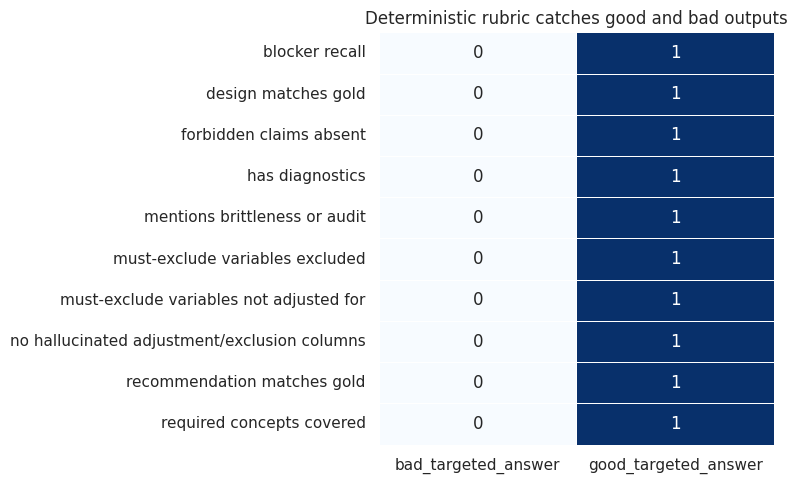

In [8]:
score_matrix = handwritten_scores.pivot_table(index='criterion', columns='answer_id', values='score', aggfunc='max').fillna(0)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(score_matrix, annot=True, cmap='Blues', cbar=False, linewidths=0.5, ax=ax)
ax.set_title('Deterministic rubric catches good and bad outputs')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The graphic gives us a way to see where the summary number is too compressed. For Scoring Hand-Written Candidate Outputs, look for where groups separate, where curves bend, or where the tails behave differently. The next decision should reflect these features, the aggregate score alone.


## 7. Blocker Recall

For high-risk causal workflows, average score is not enough. Missing a blocker can be worse than missing several minor style requirements.

Blocker recall asks: of the known high-risk blockers in the case, how many did the output mention?

In [9]:
# Section focus: 7. Blocker Recall.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def blocker_recall(answer, case):
    """Carry out the blocker recall step used in the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    answer : object
        Model answer or parsed answer object being scored against the expected behavior.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Intermediate result produced by the blocker recall calculation and reused by later cells.
    """
    text = answer_text(answer)
    blockers = case['gold_blockers']
    if not blockers:
        return np.nan
    hits = [blocker for blocker in blockers if contains_any(text, [blocker])]
    return len(hits) / len(blockers)


def summarize_answer_quality(answer_records, cases=EVAL_CASES):
    """Summarize answer quality for the 22. Evaluating AI Outputs in Causal Workflows analysis.
    
    Parameters
    ----------
    answer_records : object
        Rows that store model answers and their evaluation fields.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    case_by_id = {case['task_id']: case for case in cases}
    rows = []
    for record in answer_records:
        answer = record['answer'] if isinstance(record['answer'], CausalWorkflowAnswer) else CausalWorkflowAnswer(**record['answer'])
        score_table = score_workflow_answer(answer, case_by_id[answer.task_id])
        rows.append({
            'answer_id': record['answer_id'],
            'task_id': answer.task_id,
            'total_score': int(score_table['score'].sum()),
            'max_score': int(len(score_table)),
            'score_rate': float(score_table['score'].mean()),
            'blocker_recall': blocker_recall(answer, case_by_id[answer.task_id]),
            'design': answer.design,
            'recommendation': answer.recommendation,
        })
    return pd.DataFrame(rows)


summarize_answer_quality(handwritten_records)

,answer_id,task_id,total_score,max_score,score_rate,blocker_recall,design,recommendation
0,good_targeted_answer,targeted_retention_offer,10,10,1.0,1.0,observational_adjustment,proceed_with_human_review
1,bad_targeted_answer,targeted_retention_offer,0,10,0.0,0.0,randomized_experiment,proceed


At this point, the score has to become an operating choice. The useful reading is which metric would change the action in Blocker Recall. When metrics conflict, ask which error the organization can least afford.


## 8. Regression Testing Prompt/Model Drift

In production, you want to compare current outputs to a baseline. The goal is not to freeze all language. The goal is to detect behavior regressions: fewer blockers caught, more hallucinated columns, less conservative recommendations, or missing diagnostics.

In [10]:
# Section focus: 8. Regression Testing Prompt/Model Drift.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

baseline_eval = pd.DataFrame([
    {'run_id': 'baseline_prompt_v1', 'task_id': 'targeted_retention_offer', 'score_rate': 1.00, 'blocker_recall': 1.00, 'parse_success': 1},
    {'run_id': 'baseline_prompt_v1', 'task_id': 'staggered_policy_rollout', 'score_rate': 0.90, 'blocker_recall': 0.50, 'parse_success': 1},
    {'run_id': 'baseline_prompt_v1', 'task_id': 'ad_click_bad_control', 'score_rate': 0.95, 'blocker_recall': 1.00, 'parse_success': 1},
])

current_eval = pd.DataFrame([
    {'run_id': 'current_prompt_v2', 'task_id': 'targeted_retention_offer', 'score_rate': 0.80, 'blocker_recall': 0.50, 'parse_success': 1},
    {'run_id': 'current_prompt_v2', 'task_id': 'staggered_policy_rollout', 'score_rate': 0.92, 'blocker_recall': 0.50, 'parse_success': 1},
    {'run_id': 'current_prompt_v2', 'task_id': 'ad_click_bad_control', 'score_rate': 0.65, 'blocker_recall': 0.00, 'parse_success': 1},
])

regression_table = current_eval.merge(
    baseline_eval,
    on='task_id',
    suffixes=('_current', '_baseline'),
)
regression_table['score_delta'] = regression_table['score_rate_current'] - regression_table['score_rate_baseline']
regression_table['blocker_recall_delta'] = regression_table['blocker_recall_current'] - regression_table['blocker_recall_baseline']
regression_table['regression_flag'] = (
    (regression_table['score_delta'] < -0.10)
    | (regression_table['blocker_recall_delta'] < -0.25)
    | (regression_table['parse_success_current'] < regression_table['parse_success_baseline'])
)
regression_table[['task_id', 'score_delta', 'blocker_recall_delta', 'regression_flag']]

,task_id,score_delta,blocker_recall_delta,regression_flag
0,targeted_retention_offer,-0.20,-0.5,True
1,staggered_policy_rollout,0.02,0.0,False
2,ad_click_bad_control,-0.30,-1.0,True


For Regression Testing Prompt/Model Drift, treat the response as a small experiment in model behavior. Separate the useful structure from the reliability problems.


## 9. Evaluation Report

An evaluation report should be boring and explicit. It should say which cases failed, why they failed, and whether the current prompt/model is allowed to ship.

In [11]:
# Section focus: 9. Evaluation Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def build_eval_report(regression_table):
    """Build the eval report object used in the 22. Evaluating AI Outputs in Causal Workflows analysis.
    
    Parameters
    ----------
    regression_table : object
        Tabular data object used as the input or output of this workflow step.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the eval report workflow.
    """
    failed = regression_table[regression_table['regression_flag']]
    lines = ['### Evaluation Regression Report', '']
    if len(failed) == 0:
        lines.append('No regressions exceeded the configured thresholds.')
    else:
        lines.append(f'{len(failed)} task(s) exceeded regression thresholds.')
        for row in failed.itertuples():
            lines.append(
                f"- `{row.task_id}`: score delta {row.score_delta:.2f}, "
                f"blocker recall delta {row.blocker_recall_delta:.2f}."
            )
    lines.append('')
    lines.append('**Release decision:** ' + ('block prompt/model update' if len(failed) else 'allow update with monitoring'))
    lines.append('')
    lines.append('**Brittleness note.** Rerun failures should be inspected before release because stochastic model behavior, parser repair, and rubric wording can all move scores.')
    return '\n'.join(lines)


eval_report = build_eval_report(regression_table)
smart_display(Markdown(eval_report))

### Evaluation Regression Report

2 task(s) exceeded regression thresholds.
- `targeted_retention_offer`: score delta -0.20, blocker recall delta -0.50.
- `ad_click_bad_control`: score delta -0.30, blocker recall delta -1.00.

**Release decision:** block prompt/model update

**Brittleness note.** Rerun failures should be inspected before release because stochastic model behavior, parser repair, and rubric wording can all move scores.

In Evaluation Report, the response is useful only if a human analyst can check it. Check whether the response keeps its reasoning close to the material it was given.


## 10. Optional Live Local Model Evaluation

Now we ask one local model to answer several benchmark cases. The model is required to produce the schema above. We parse, score, and inspect failures.

In [12]:
# Section focus: 10. Optional Live Local Model Evaluation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

EVAL_SYSTEM_MESSAGE = """
You are a careful causal inference evaluation subject. Answer with cautious causal reasoning.
Do not invent columns. Do not use post-treatment variables as controls. Return final JSON only.
""".strip()


def answer_schema_prompt():
    """Carry out the answer schema prompt step used in the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the answer schema prompt workflow.
    """
    return """
Return one CausalWorkflowAnswer JSON object only.

Schema:
{
  "task_id": "string",
  "design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | instrumental_variables | do_not_analyze_yet",
  "estimand_summary": "string",
  "adjustment_set": ["string"],
  "excluded_variables": ["string"],
  "diagnostics": ["string"],
  "risks": ["string"],
  "recommendation": "proceed | proceed_with_human_review | needs_more_information | do_not_proceed",
  "final_answer": "string",
  "brittleness_note": "string",
  "confidence": "low | medium | high"
}
""".strip()


def build_case_prompt(case):
    """Build the case prompt object used in the 22. Evaluating AI Outputs in Causal Workflows analysis.
    
    Parameters
    ----------
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the case prompt workflow.
    """
    public_case = {key: case[key] for key in ['task_id', 'prompt', 'known_columns']}
    return f"""
{answer_schema_prompt()}

Case:
{json.dumps(public_case, indent=2)}

Requirements:
- Use only known columns in adjustment_set and excluded_variables.
- Exclude post-treatment or bad-control variables.
- Recommend diagnostics appropriate to the design.
- Be conservative about rollout decisions.
- Mention output brittleness or the need for audit/human review.
""".strip()


print(build_case_prompt(EVAL_CASES[1])[:2400])

Return one CausalWorkflowAnswer JSON object only.

Schema:
{
  "task_id": "string",
  "design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | instrumental_variables | do_not_analyze_yet",
  "estimand_summary": "string",
  "adjustment_set": ["string"],
  "excluded_variables": ["string"],
  "diagnostics": ["string"],
  "risks": ["string"],
  "recommendation": "proceed | proceed_with_human_review | needs_more_information | do_not_proceed",
  "final_answer": "string",
  "brittleness_note": "string",
  "confidence": "low | medium | high"
}

Case:
{
  "task_id": "targeted_retention_offer",
  "prompt": "High-risk subscribers were targeted for a concierge retention offer. Outcome is renewal within 60 days. Columns: concierge_offer, renewed_60d, risk_score_pre, prior_usage_30d, support_contacts_after_offer, segment.",
  "known_columns": [
    "concierge_offer",
    "renewed_60d",
    "risk_score_pre",
    "prior_usage_30d",
    "suppo

Read Optional Live Local Model Evaluation as a draft from an unreliable assistant. Treat the checkable pieces as signal and the unsupported pieces as design feedback for the next run.


In [13]:
# Section focus: 10. Optional Live Local Model Evaluation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

try:
    from notebooks._shared.local_llm import clear_loaded_model_cache, local_chat
    from notebooks._shared.structured_outputs import parse_pydantic_output
except Exception as exc:
    clear_loaded_model_cache = None
    local_chat = None
    parse_pydantic_output = None
    print(f'Could not import shared LLM helpers: {exc}')


def release_model_memory():
    """Carry out the release model memory step used in the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the release model memory workflow.
    """
    if clear_loaded_model_cache is None:
        return
    try:
        clear_loaded_model_cache()
    except Exception as exc:
        print(f'Could not clear loaded model cache: {exc}')

Optional Live Local Model Evaluation should show whether the model can follow the evidence without overclaiming.


In [14]:
# Section focus: 10. Optional Live Local Model Evaluation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def parse_workflow_answer(raw_output, task_id):
    """Carry out the parse workflow answer step used in the 22. Evaluating AI Outputs in Causal Workflows workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    task_id : object
        The task id setting that controls the parse workflow answer calculation in this notebook.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the parse workflow answer workflow.
    """
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    defaults = {**ANSWER_DEFAULTS, 'task_id': task_id}
    return parse_pydantic_output(
        raw_output,
        CausalWorkflowAnswer,
        scalar_fields=['task_id', 'design', 'estimand_summary', 'recommendation', 'final_answer', 'brittleness_note', 'confidence'],
        list_fields=['adjustment_set', 'excluded_variables', 'diagnostics', 'risks'],
        field_aliases=ANSWER_FIELD_ALIASES,
        value_aliases=ANSWER_VALUE_ALIASES,
        defaults=defaults,
    )


live_answer_records = []
live_failures = []

if RUN_LIVE_LOCAL_LLM and local_chat is not None and parse_pydantic_output is not None:
    release_model_memory()
    try:
        for case in EVAL_CASES[:MODEL_COMPARISON_CASE_LIMIT]:
            print(f'Running live evaluation case: {case["task_id"]}')
            raw = local_chat(
                build_case_prompt(case),
                system_message=EVAL_SYSTEM_MESSAGE,
                model_id=MODEL_ID,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                seed=SEED,
                enabled=RUN_LIVE_LOCAL_LLM,
            )
            try:
                parsed = parse_workflow_answer(raw, case['task_id'])
                live_answer_records.append({'answer_id': f'{MODEL_ID}:{case["task_id"]}', 'answer': parsed.parsed})
                if parsed.notes:
                    print(f'{case["task_id"]} parser notes:', parsed.notes)
            except Exception as exc:
                live_failures.append({'task_id': case['task_id'], 'error': repr(exc), 'raw_preview': raw[:500]})
    finally:
        release_model_memory()
else:
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local model evaluation.')

if live_answer_records:
    live_scores = evaluate_answers(live_answer_records)
    smart_display(summarize_answer_quality(live_answer_records))
else:
    live_scores = pd.DataFrame()
    print('No live answers to score yet.')

if live_failures:
    smart_display(pd.DataFrame(live_failures))

Running live evaluation case: randomized_email_holdout
Running live evaluation case: targeted_retention_offer
Running live evaluation case: staggered_policy_rollout


,answer_id,task_id,total_score,max_score,score_rate,blocker_recall,design,recommendation
0,Qwen/Qwen2.5-14B-Instruct:randomized_email_hol...,randomized_email_holdout,9,10,0.9,NaN,randomized_experiment,proceed_with_human_review
1,Qwen/Qwen2.5-14B-Instruct:targeted_retention_o...,targeted_retention_offer,8,10,0.8,0.0,observational_adjustment,proceed_with_human_review
2,Qwen/Qwen2.5-14B-Instruct:staggered_policy_rol...,staggered_policy_rollout,6,10,0.6,0.0,difference_in_differences,proceed_with_human_review


Read Optional Live Local Model Evaluation with a simple standard. The generated text has to preserve the design, not replace it.


In [15]:
if len(live_scores):
    smart_display(live_scores.pivot_table(index='criterion', columns='task_id', values='score', aggfunc='max').fillna(0))
else:
    print('No live score matrix yet.')

task_id,randomized_email_holdout,staggered_policy_rollout,targeted_retention_offer
criterion,,,
blocker recall,1,0,0
design matches gold,1,1,1
forbidden claims absent,1,1,1
has diagnostics,1,1,1
mentions brittleness or audit,1,0,1
must-exclude variables excluded,1,1,1
must-exclude variables not adjusted for,1,1,1
no hallucinated adjustment/exclusion columns,1,1,1
recommendation matches gold,1,0,1


This table is the quantitative checkpoint for Optional Live Local Model Evaluation. Compare the rows by asking which one would change model choice, threshold setting, review priority, or guardrail design.


## 11. Optional All-Model Comparison

Finally, we run the same benchmark cases across all available local models. The comparison clears model memory between model families to reduce GPU memory fragility.

In [16]:
# Section focus: 11. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def run_all_model_eval(models_to_compare=MODELS_TO_COMPARE, cases=EVAL_CASES):
    """Run the all model eval workflow for the 22. Evaluating AI Outputs in Causal Workflows analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    failures = []
    selected_cases = cases[:MODEL_COMPARISON_CASE_LIMIT]
    if local_chat is None or parse_pydantic_output is None:
        return pd.DataFrame(), [{'error': 'shared LLM helpers unavailable'}]

    for label, model_id, role in models_to_compare:
        release_model_memory()
        print(f'Running {label}: {model_id}')
        try:
            answer_records = []
            for case in selected_cases:
                try:
                    raw = local_chat(
                        build_case_prompt(case),
                        system_message=EVAL_SYSTEM_MESSAGE,
                        model_id=model_id,
                        max_new_tokens=COMPACT_MAX_NEW_TOKENS,
                        temperature=TEMPERATURE,
                        seed=SEED,
                        enabled=True,
                    )
                    parsed = parse_workflow_answer(raw, case['task_id'])
                    answer_records.append({'answer_id': f'{label}:{case["task_id"]}', 'answer': parsed.parsed})
                    quality = summarize_answer_quality([answer_records[-1]]).iloc[0].to_dict()
                    rows.append({
                        'model': label,
                        'model_id': model_id,
                        'role': role,
                        'task_id': case['task_id'],
                        'design': parsed.parsed.design,
                        'recommendation': parsed.parsed.recommendation,
                        'score_rate': quality['score_rate'],
                        'blocker_recall': quality['blocker_recall'],
                        'parser_notes': '; '.join(parsed.notes),
                    })
                except Exception as exc:
                    failures.append({'model': label, 'model_id': model_id, 'task_id': case['task_id'], 'error': repr(exc)})
        finally:
            release_model_memory()
    return pd.DataFrame(rows), failures


if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    model_eval_results, model_eval_failures = run_all_model_eval()
else:
    model_eval_results = pd.DataFrame()
    model_eval_failures = []
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct
Running Phi mini: microsoft/Phi-3.5-mini-instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


The evaluation in Optional All-Model Comparison is less about style and more about whether the causal reasoning is controllable.


In [17]:
if len(model_eval_results):
    smart_display(model_eval_results.sort_values(['score_rate', 'blocker_recall', 'model'], ascending=[False, False, True]).reset_index(drop=True))
else:
    print('No model evaluation results yet.')

if model_eval_failures:
    smart_display(pd.DataFrame(model_eval_failures))
else:
    print('No failed model details because the full comparison was skipped or all calls parsed.')

,model,model_id,role,task_id,design,recommendation,score_rate,blocker_recall,parser_notes
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,Invalid JSON: expected value at line 1 column ...
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,Input should be a valid array; design: fuzzy-n...
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,Invalid JSON: expected value at line 1 column ...
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,
5,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,
6,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,randomized_email_holdout,randomized_experiment,proceed_with_human_review,0.9,NaN,
7,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,targeted_retention_offer,observational_adjustment,proceed_with_human_review,0.8,0.0,
8,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,targeted_retention_offer,observational_adjustment,proceed_with_human_review,0.8,0.0,Invalid JSON: expected value at line 1 column ...
9,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,targeted_retention_offer,observational_adjustment,proceed_with_human_review,0.8,0.0,


,model,model_id,task_id,error
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,randomized_email_holdout,"ValueError(""No valid CausalWorkflowAnswer foun..."
1,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,staggered_policy_rollout,"ValueError(""No valid CausalWorkflowAnswer foun..."


This result sits between model performance and the operating policy. The useful reading is which metric would change the action in Optional All-Model Comparison. Use disagreement among metrics to make the governance priority explicit.


In [18]:
if len(model_eval_results):
    model_summary = (
        model_eval_results
        .groupby(['model', 'model_id', 'role'], as_index=False)
        .agg(
            mean_score_rate=('score_rate', 'mean'),
            min_score_rate=('score_rate', 'min'),
            mean_blocker_recall=('blocker_recall', 'mean'),
            cases=('task_id', 'nunique'),
        )
        .sort_values(['mean_score_rate', 'mean_blocker_recall', 'min_score_rate'], ascending=False)
    )
    smart_display(model_summary)
else:
    print('No model summary yet.')

,model,model_id,role,mean_score_rate,min_score_rate,mean_blocker_recall,cases
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,0.800000,0.7,0.0,3
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,0.800000,0.7,0.0,3
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,0.766667,0.6,0.0,3
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,0.766667,0.6,0.0,3
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,0.733333,0.6,0.0,3
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,0.733333,0.6,0.0,3
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,0.700000,0.6,0.0,3
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,0.666667,0.5,0.0,3
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,0.400000,0.4,0.0,1


The metric result should be read as an operating tradeoff. In Optional All-Model Comparison, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The next step is to connect the metric with cost, risk, threshold choice, or the stakeholder decision.


## 12. Evaluation Checklist

A serious evaluation harness for AI-assisted causal work should include:

1. Gold cases from real failure modes.
2. Structured output schemas.
3. Parse-success metrics.
4. Design-selection accuracy.
5. Bad-control and variable-timing checks.
6. Hallucinated-column checks.
7. Blocker recall.
8. Recommendation conservatism.
9. Prompt/model regression tests.
10. Rerun stability checks for brittle live-model behavior.

## 13. Exercises

1. Add a case where the model must recommend instrumental variables.
2. Add a case where a regression discontinuity score is manipulable near the cutoff.
3. Add partial credit for required concepts instead of all-or-nothing scoring.
4. Add an LLM-as-judge layer and compare it to the deterministic rubric. Where does the judge disagree?
5. Create a regression threshold that blocks release if blocker recall drops, even when average score is stable.
6. Run all model families and inspect which failures are model-specific versus prompt-specific.

## 14. Key Takeaways

- Causal AI outputs should be evaluated for decision safety alongside readability.
- Deterministic rubrics are the backbone of reliable evaluation.
- Blocker recall matters more than average score in high-risk workflows.
- Hallucinated columns and post-treatment controls are easy to test and should always be tested.
- Evaluation itself is brittle: prompts, parsers, rubrics, model versions, and decoding settings can change outcomes. Treat evaluation as a monitored system.

## References

- Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92. [https://doi.org/10.1145/3458723](https://doi.org/10.1145/3458723)
- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *arXiv*. [https://doi.org/10.48550/arXiv.1706.03762](https://doi.org/10.48550/arXiv.1706.03762)
- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
